# Logistic Regression Classification

В этом ноутбуке разберём:
- бинарную классификацию
- вероятности классов и порог 0.5
- регуляризации L1, L2, ElasticNet
- метрики: Accuracy, Precision, Recall, F1, ROC-AUC, Log Loss

## 1. Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, log_loss,
                             confusion_matrix, roc_curve)

np.random.seed(42)
plt.rcParams['figure.figsize'] = (7, 5)

## 2. Генерация данных и график

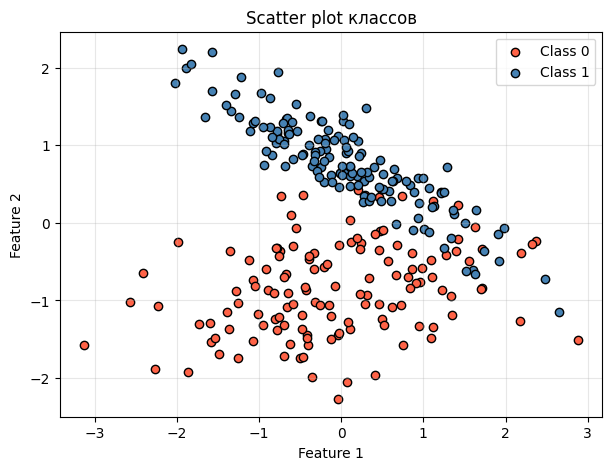

In [2]:
X, y = make_classification(n_samples=400, n_features=2, n_redundant=0,
                           n_informative=2, n_clusters_per_class=1,
                           class_sep=1.2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], c='tomato', label='Class 0', edgecolor='k')
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], c='steelblue', label='Class 1', edgecolor='k')
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.title('Scatter plot классов')
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 3. Обучение модели и вероятности классов

In [3]:
model = LogisticRegression()
model.fit(X_train, y_train)

probs = model.predict_proba(X_test)
df_probs = pd.DataFrame(probs[:10], columns=['P(class=0)', 'P(class=1)'])
df_probs['true'] = y_test[:10]
df_probs['pred (порог 0.5)'] = (probs[:10, 1] >= 0.5).astype(int)
df_probs

,P(class=0),P(class=1),true,pred (порог 0.5)
0,0.028135,0.971865,1,1
1,0.014751,0.985249,1,1
2,0.722183,0.277817,0,0
3,0.990499,0.009501,0,0
4,0.305846,0.694154,0,1
5,0.024203,0.975797,1,1
6,0.177465,0.822535,1,1
7,0.073155,0.926845,0,1
8,0.049853,0.950147,0,1
9,0.021293,0.978707,1,1


Модель возвращает **вероятности** для каждого класса. По умолчанию используется **порог 0.5**: если P(class=1) ≥ 0.5 → предсказывается класс 1.

## 4. Decision boundary (граница 0.5)

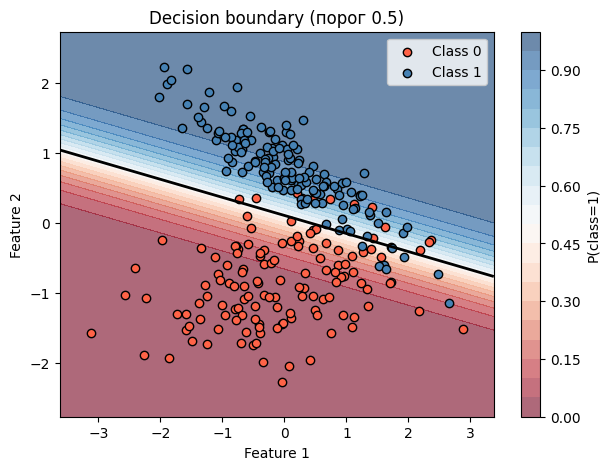

In [4]:
xx, yy = np.meshgrid(np.linspace(X_train[:,0].min()-0.5, X_train[:,0].max()+0.5, 300),
                     np.linspace(X_train[:,1].min()-0.5, X_train[:,1].max()+0.5, 300))
Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.6)
plt.colorbar(label='P(class=1)')
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], c='tomato', edgecolor='k', label='Class 0')
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], c='steelblue', edgecolor='k', label='Class 1')
plt.title('Decision boundary (порог 0.5)')
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.legend(); plt.show()

Чёрная линия — это место, где P(class=1) = 0.5. Слева от неё модель предсказывает класс 0, справа — класс 1.

## 5. Метрики качества

In [5]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(f'Accuracy : {accuracy_score(y_test, y_pred):.3f}')
print(f'Precision: {precision_score(y_test, y_pred):.3f}')
print(f'Recall   : {recall_score(y_test, y_pred):.3f}')
print(f'F1-score : {f1_score(y_test, y_pred):.3f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_proba):.3f}')
print(f'Log Loss : {log_loss(y_test, y_proba):.3f}')

Accuracy : 0.908
Precision: 0.852
Recall   : 0.963
F1-score : 0.904
ROC-AUC  : 0.960
Log Loss : 0.258


## 6. Confusion matrix

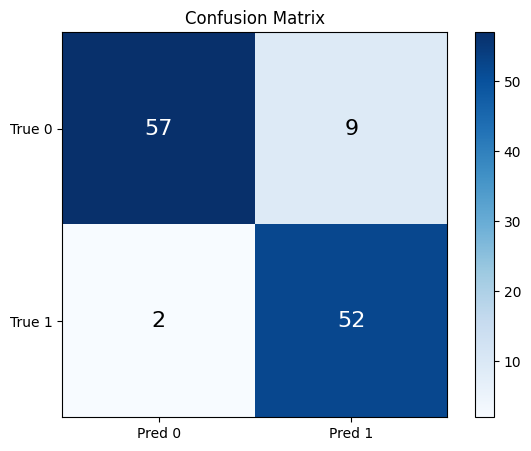

In [6]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots()
im = ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=16,
                color='white' if cm[i, j] > cm.max()/2 else 'black')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred 0', 'Pred 1'])
ax.set_yticklabels(['True 0', 'True 1'])
ax.set_title('Confusion Matrix')
plt.colorbar(im); plt.show()

## 7. ROC curve

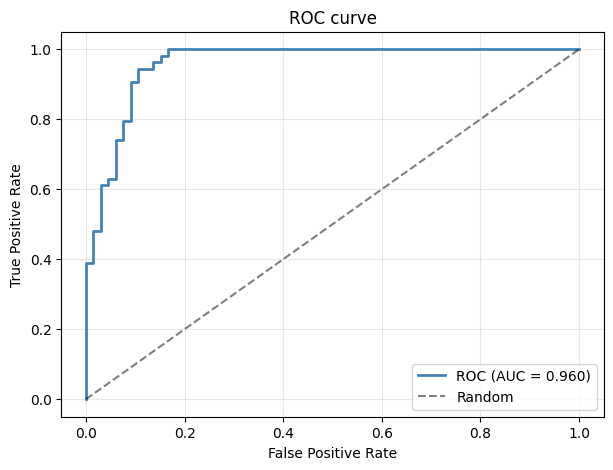

In [7]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC curve')
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 8. Регуляризации L1, L2, ElasticNet

- **L1 (Lasso)** — обнуляет неважные признаки;
- **L2 (Ridge)** — уменьшает все веса, защищает от переобучения;
- **ElasticNet** — комбинация L1 и L2.

In [8]:
models = {
    'L1': LogisticRegression(penalty='l1', solver='saga', C=1.0, max_iter=5000),
    'L2': LogisticRegression(penalty='l2', solver='saga', C=1.0, max_iter=5000),
    'ElasticNet': LogisticRegression(penalty='elasticnet', solver='saga',
                                     l1_ratio=0.5, C=1.0, max_iter=5000),
}

results = []
for name, m in models.items():
    m.fit(X_train, y_train)
    p = m.predict(X_test)
    pr = m.predict_proba(X_test)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, p),
        'Precision': precision_score(y_test, p),
        'Recall': recall_score(y_test, p),
        'F1': f1_score(y_test, p),
        'ROC-AUC': roc_auc_score(y_test, pr),
        'LogLoss': log_loss(y_test, pr),
    })

df = pd.DataFrame(results).set_index('Model')
df.round(3)

,Accuracy,Precision,Recall,F1,ROC-AUC,LogLoss
Model,,,,,,
L1,0.908,0.852,0.963,0.904,0.96,0.253
L2,0.908,0.852,0.963,0.904,0.96,0.258
ElasticNet,0.908,0.852,0.963,0.904,0.96,0.255


## 9. Bar chart метрик для разных регуляризаций

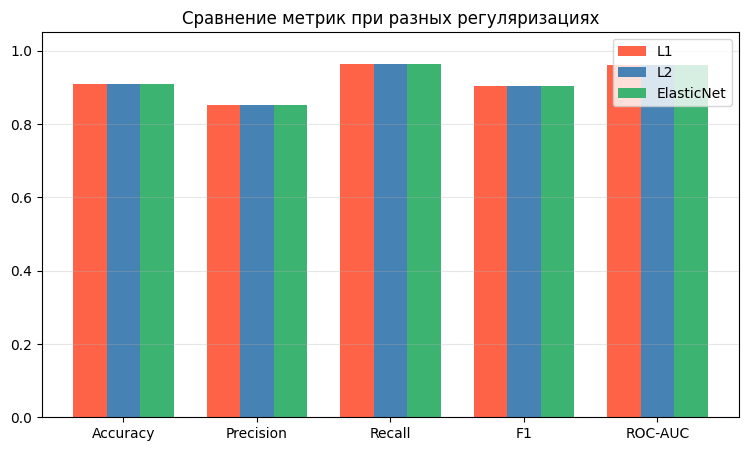

In [9]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25
colors = ['tomato', 'steelblue', 'mediumseagreen']

fig, ax = plt.subplots(figsize=(9, 5))
for i, name in enumerate(df.index):
    ax.bar(x + (i-1)*width, df.loc[name, metrics].values, width, label=name, color=colors[i])

ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_title('Сравнение метрик при разных регуляризациях')
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.show()

#**Общий итог:**

- Logistic Regression выдаёт **вероятности** через сигмоиду, а не сразу классы.
- Порог **0.5** — стандартный, но его можно менять под задачу (например, повысить Recall).
- **Регуляризация** помогает бороться с переобучением: L1 — отбор признаков, L2 — сглаживание весов, ElasticNet — гибрид.
- Для оценки используют **набор метрик**, потому что одна Accuracy может вводить в заблуждение (особенно при дисбалансе классов).